# Object Midline Detection

This notebook extracts a **midline** (medial axis / spine) through each object in a
single-channel image — e.g. DAPI from a Xenium run.

For every detected structure it computes three candidate midlines so they can be
compared side by side:

1. **Skeleton longest path** — skeletonise the mask, build a branch graph, take the
   geodesic-longest endpoint-to-endpoint path.
2. **Geodesic path (distance-transform-weighted)** — Dijkstra between the two extreme
   points, with travel cost that favours pixels far from the boundary (the medial axis).
3. **Smoothed spline** — a B-spline fit to (2), clipped back inside the mask. This is
   usually the most useful form for downstream work (uniform arc-length sampling,
   projecting transcripts onto a 1D coordinate, etc.).

## Dependencies

All packages are on PyPI:

```
pip install numpy tifffile scikit-image scipy matplotlib skan
```

In [22]:
import numpy as np
import tifffile
import json
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import (skeletonize, remove_small_objects,
                                remove_small_holes, closing, disk)
from skimage.measure import label, regionprops, find_contours
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from scipy.interpolate import splprep, splev
from skimage.graph import route_through_array
from scipy.spatial.distance import cdist
from skan import Skeleton, summarize
import networkx as nx
import matplotlib.pyplot as plt

## Parameters

All the tunable settings live here so you don't have to hunt through the code. The
defaults work on the example image, but the masking parameters are the ones you'll
most likely need to adjust for a new dataset.

- **`INPUT_PATH`** — the image to analyse.
- **`SMOOTH_SIGMA`** — Gaussian blur (in px) applied before thresholding. Higher values
  suppress more of the DAPI speckle but also round off fine structure; lower values keep
  detail but may fragment objects.
- **`MIN_OBJECT_AREA`** — objects smaller than this (in px) are discarded as
  debris. Raise it if specks are surviving the mask; lower it if real structures vanish.
- **`MIN_HOLE_AREA`** — interior gaps smaller than this (in px) are filled, so textured
  tissue reads as one solid object rather than a sponge.
- **`CLOSE_RADIUS`** — radius (in px) of the morphological closing that bridges thin gaps
  and smooths the boundary before skeletonising.

In [23]:
INPUT_PATH        = './inputs/Xenium_DAPI_multi_block2_slice2.tif'
SMOOTH_SIGMA    = 4.0      # px, Gaussian blur before thresholding (suppress DAPI graininess)
MIN_OBJECT_AREA = 8000     # px, drop debris
MIN_HOLE_AREA   = 5000     # px, fill interior gaps
CLOSE_RADIUS    = 5        # px, morphological closing to bridge thin gaps

## Loading and masking

`load_mask` turns the raw input image into a cleaned boolean mask of the structures.
It returns both the raw intensities (kept for display) and the mask.

The steps:

1. **Read** the TIFF as float.
2. **Blur** with a Gaussian (`SMOOTH_SIGMA`) to suppress the grainy DAPI texture, so the
   threshold sees solid tissue rather than thousands of speckles.
3. **Threshold** with global Otsu on the blurred intensities to separate tissue from
   background.
4. **Clean up** the binary mask: fill enclosed holes, remove small interior gaps
   (`MIN_HOLE_AREA`), close thin gaps and smooth the boundary (`CLOSE_RADIUS`), and drop
   debris below `MIN_OBJECT_AREA`.

In [24]:
def load_mask(path):
    """16-bit single channel -> cleaned boolean mask."""
    raw = tifffile.imread(path).astype(np.float32)
    # blur to tame the speckle, then global Otsu on the 16-bit intensities
    blurred = gaussian(raw, sigma=SMOOTH_SIGMA, preserve_range=True)
    thr = threshold_otsu(blurred)
    mask = blurred > thr
    # morphological cleanup
    mask = binary_fill_holes(mask)
    mask = remove_small_holes(mask, max_size=MIN_HOLE_AREA)
    mask = closing(mask, disk(CLOSE_RADIUS))
    mask = remove_small_objects(mask, max_size=MIN_OBJECT_AREA)
    return raw, mask

## Method 1 — Skeleton longest path

This is the "proper" version of what the inscribed-circles plugin approximates. Rather
than greedily walking from circle to circle, it skeletonises the object and explicitly
finds the longest path through the skeleton.

The steps:

1. **Skeletonise** the object to a 1-px-wide centreline. (Objects with a negligible
   skeleton return `None` and are skipped.)
2. **Build a graph** with `skan`: each skeleton branch becomes an edge weighted by its
   length, and the endpoints/junctions become nodes.
3. **Find the longest path** by running Dijkstra from every endpoint and keeping the
   endpoint-to-endpoint pair with the greatest total distance.
4. **Stitch the coordinates** of the branches along that path into a single ordered curve,
   flipping each branch as needed so the points run continuously end to end.

In [25]:
def longest_skeleton_path(component):
    skel = skeletonize(component)
    if skel.sum() < 5:
        return None
    sk = Skeleton(skel)
    df = summarize(sk, separator='-')
    G = nx.Graph()
    for i, row in df.iterrows():
        G.add_edge(int(row['node-id-src']), int(row['node-id-dst']),
                   weight=row['branch-distance'], branch=i)
    endpoints = [n for n in G.nodes if G.degree[n] == 1] or list(G.nodes)
    best = (0, None)
    for a in endpoints:
        lengths = nx.single_source_dijkstra_path_length(G, a, weight='weight')
        for b, L in lengths.items():
            if L > best[0] and b in endpoints:
                best = (L, (a, b))
    if best[1] is None:
        return None
    node_path = nx.shortest_path(G, *best[1], weight='weight')
    coords = []
    for a, b in zip(node_path[:-1], node_path[1:]):
        pts = sk.path_coordinates(G[a][b]['branch'])
        if coords and np.allclose(coords[-1], pts[-1]):
            pts = pts[::-1]
        coords.extend(pts.tolist())
    return np.array(coords)

## Method 2 — Distance-transform-weighted geodesic path

This finds a midline without ever treating the skeleton as a discrete graph, which makes
it more robust to a rough or noisy boundary than Method 1.

The steps:

1. **Distance transform** the object so each interior pixel knows how far it is from the
   boundary. The ridge of high values runs down the medial axis.
2. **Build a cost map** as `(max_distance − distance)`, so travelling near the centre is
   cheap and travelling near the edge is expensive. The path is therefore pulled toward
   the medial axis without it being computed explicitly.
3. **Pick the two extreme points** as the farthest-apart pair of skeleton pixels. (The
   skeleton is used only to choose endpoints here, not to trace the route.)
4. **Route between them** with `route_through_array`, a least-cost path on the pixel grid,
   yielding the midline.

In [26]:
def geodesic_longest_path(component):
    dt = distance_transform_edt(component)
    cost = (dt.max() - dt) + 0.5            # cheaper to travel near the medial axis
    skel = skeletonize(component)
    ys, xs = np.where(skel)
    if len(xs) < 5:
        return None
    pts = np.column_stack([ys, xs])
    d = cdist(pts, pts)
    i, j = np.unravel_index(np.argmax(d), d.shape)
    path, _ = route_through_array(cost, tuple(pts[i]), tuple(pts[j]),
                                  fully_connected=True, geometric=True)
    return np.array(path)

## Method 3 — Smoothed spline

Method 2 returns a pixel-accurate path that wiggles with the data. This fits a smooth
B-spline through it, giving a clean parametric curve — usually the most useful form for
downstream work, since you can resample it at uniform arc length and project other
measurements (e.g. transcript positions) onto a 1D coordinate along the structure.

The steps:

1. **Fit a cubic B-spline** (`splprep`) through the input path. The smoothing factor
   scales with path length via `smoothing_mult` — higher values give a smoother, looser
   fit; lower values hug the original path more tightly.
2. **Resample** the fitted spline at `n_out` evenly-spaced points (`splev`).
3. **Clip to the mask** — discard any resampled points that fall outside the structure, so
   the smoothing can't bow the curve out through a concave boundary. (Paths short enough to
   have no valid interior points fall back to the unclipped curve.)

In [27]:
def smooth_path(coords, mask, n_out=120, smoothing_mult=4):
    if coords is None or len(coords) < 4:
        return coords
    tck, _ = splprep([coords[:, 1], coords[:, 0]], s=len(coords)*smoothing_mult, k=3)
    u = np.linspace(0, 1, n_out)
    x, y = splev(u, tck)
    out = np.column_stack([y, x])
    # clip back inside the mask so smoothing can't push the curve out of the structure
    yy = np.clip(out[:, 0].round().astype(int), 0, mask.shape[0]-1)
    xx = np.clip(out[:, 1].round().astype(int), 0, mask.shape[1]-1)
    inside = mask[yy, xx]
    return out[inside] if inside.any() else out

## Run: load, mask, and label

With the functions defined, build the mask from the input image and split it into
individual structures. `label` assigns each object a unique integer ID, and
`regionprops` gives a per-object handle to iterate over in the next cell. The printout is a
quick sanity check — confirm the structure count matches what you expect before computing
midlines.

If the count looks wrong (debris counted as objects, or touching structures merged into
one), adjust the masking parameters above rather than anything downstream — every later
step works off these labels.

mask px=650594  structures=23


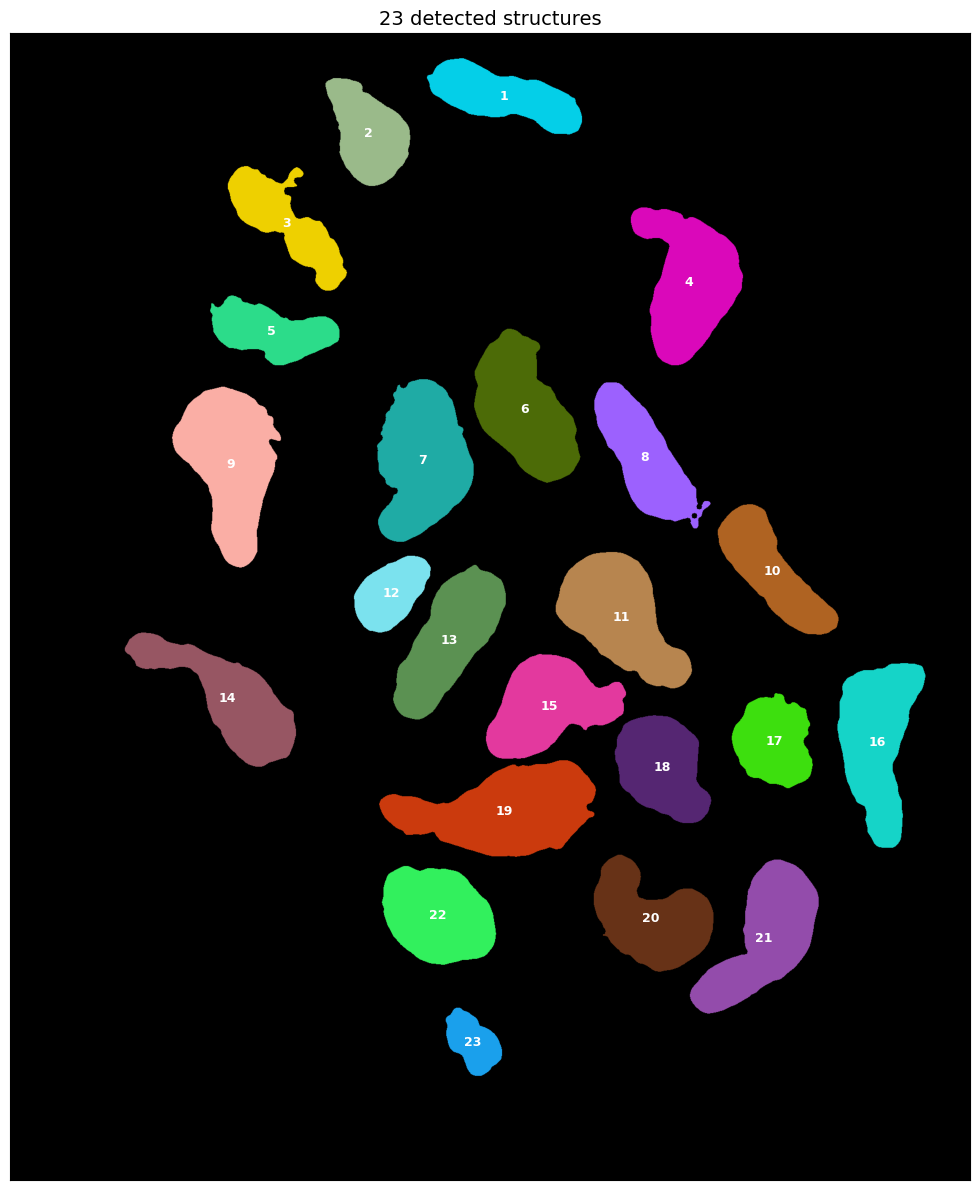

In [28]:
raw, mask = load_mask(INPUT_PATH)
labels = label(mask)
props  = regionprops(labels)
print(f"mask px={mask.sum()}  structures={len(props)}")

# --- sanity-check display: each object a distinct colour, tagged with its ID ---
rng = np.random.default_rng(0)
lut = rng.random((labels.max() + 1, 3))
lut[0] = 0                                  # background -> black
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(lut[labels])
ax.set_title(f"{labels.max()} detected structures", fontsize=14)
ax.set_xticks([]); ax.set_yticks([])
for prop in props:
    y, x = prop.centroid
    ax.text(x, y, str(prop.label), color='white', fontsize=9,
            ha='center', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Save the mask

Write the detected objects to disk as a PNG for quick viewing and record-keeping.

In [29]:
plt.imsave('./outputs/detected_objects.png', labels)
print("saved labels (png)")

saved labels (png)


## Compare the three midlines

Run all three methods on every structure and plot them side by side for comparison. Each
panel shows the raw DAPI (contrast-stretched to the 99th percentile so the tissue is
visible without blowing out bright spots), the detected object outlines in yellow, and one
method's midline:

- **Panel 1** — skeleton longest path (cyan)
- **Panel 2** — geodesic path (green)
- **Panel 3** — smoothed spline (magenta)

The yellow outlines make it easy to see where each midline sits relative to the structure
it belongs to — and to spot any segmentation errors.

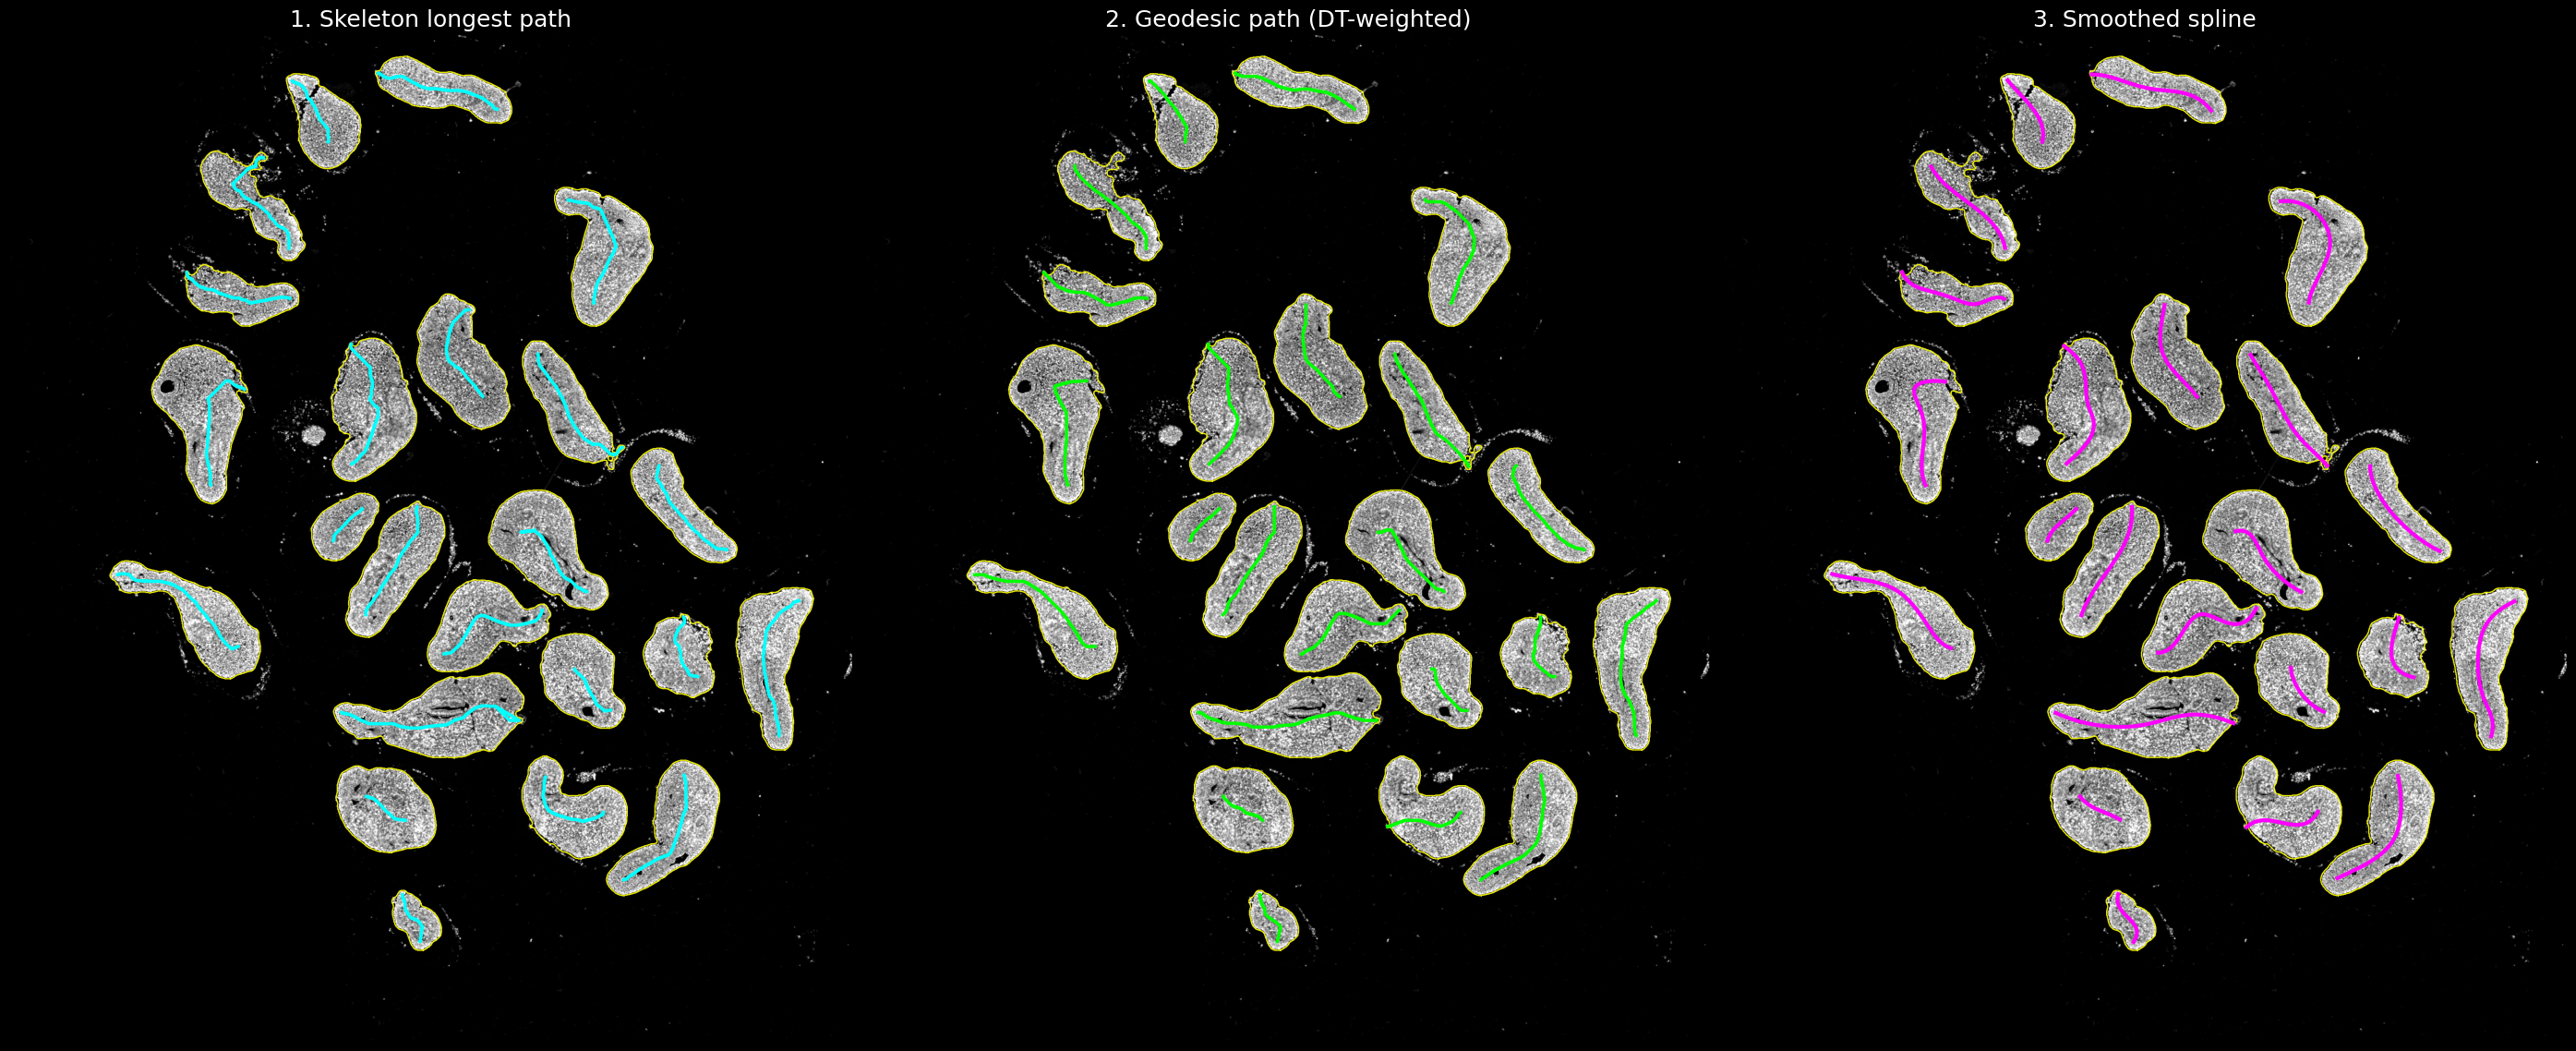

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(28, 12), facecolor='black')
disp = np.clip(raw / np.percentile(raw, 99) * 255, 0, 255)   # display stretch
for ax, t in zip(axes, ['1. Skeleton longest path',
                        '2. Geodesic path (DT-weighted)',
                        '3. Smoothed spline']):
    ax.imshow(disp, cmap='gray'); ax.set_title(t, color='white', fontsize=18)
    ax.set_xticks([]); ax.set_yticks([])

for prop in props:
    comp = labels == prop.label

    # draw the object outline on all three panels
    for contour in find_contours(comp.astype(float), 0.5):
        for ax in axes:
            ax.plot(contour[:, 1], contour[:, 0], color='yellow', lw=1.0, alpha=0.9)

    p1 = longest_skeleton_path(comp)
    if p1 is not None:
        axes[0].plot(p1[:,1], p1[:,0], color='cyan', lw=2.5)
    p2 = geodesic_longest_path(comp)
    if p2 is not None:
        axes[1].plot(p2[:,1], p2[:,0], color='lime', lw=2.5)
        p3 = smooth_path(p2, comp)
        if p3 is not None:
            axes[2].plot(p3[:,1], p3[:,0], color='magenta', lw=3)

plt.tight_layout()
plt.show()

In [31]:
plt.savefig('./outputs/midline_tif_comparison.png', dpi=110,
            facecolor='black', bbox_inches='tight')
print("saved")

saved


<Figure size 640x480 with 0 Axes>

## Export all midlines as GeoJSON

Rather than committing to one method now, export all three for every structure. Each
midline becomes a `LineString` feature tagged with its object `label` and the `method` that
produced it, all in a single GeoJSON `FeatureCollection`. On reload you can filter to one
method, or compare them per object, without rerunning anything.

GeoJSON is plain text, reloads directly into `geopandas`/`shapely`, and is read natively by
QuPath and napari. The file is written with the standard-library `json` module, so no extra
dependency is needed to create it.

**Coordinate convention:** paths are computed in `(row, col)` image order, but GeoJSON
expects `(x, y)`, so coordinates are written as `[col, row]`. Image `y` increases
*downwards* — overlaying on the image with `imshow` is already correct, but plotting on
conventional axes needs the y-axis inverted.

In [32]:
def all_paths(comp):
    """Return {method_name: path_or_None} for one object."""
    geo = geodesic_longest_path(comp)
    return {
        "skeleton_longest_path": longest_skeleton_path(comp),
        "geodesic_dt":           geo,
        "smoothed_spline":       smooth_path(geo, comp),  # reuses the geodesic path
    }

features = []
for prop in props:
    comp = labels == prop.label
    for method, path in all_paths(comp).items():
        if path is None or len(path) < 2:
            continue
        # paths are (row, col) = (y, x); GeoJSON expects [x, y]
        coords = [[float(x), float(y)] for y, x in path]
        features.append({
            "type": "Feature",
            "properties": {"label": int(prop.label), "method": method},
            "geometry": {"type": "LineString", "coordinates": coords},
        })

fc = {"type": "FeatureCollection", "features": features}
with open('./outputs/midlines.geojson', 'w') as f:
    json.dump(fc, f)
print(f"wrote {len(features)} features "
      f"({len(props)} objects x up to 3 methods)")

wrote 69 features (23 objects x up to 3 methods)
